#  **DecodeLabs —week1**

In [1]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid', font_scale=0.95)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': '#F8FAFC'})

PALETTE   = ['#2563EB','#16A34A','#DC2626','#D97706','#7C3AED','#0891B2','#DB2777']
INPUT     = '/mnt/user-data/uploads/Dataset_for_Data_Analytics.xlsx'
ID_COL    = 'OrderID'
DATE_COL  = 'Date'
NUM_COLS  = ['Quantity','UnitPrice','ItemsInCart','TotalPrice']
CAT_COLS  = ['Product','PaymentMethod','OrderStatus','CouponCode','ReferralSource',
             'ShippingAddress','CustomerID','TrackingNumber']
FINANCIAL = ['UnitPrice','TotalPrice']
TEXT_PROP = ['Product','PaymentMethod','OrderStatus','CouponCode','ReferralSource']

# **Phase 1 — Exploratory Data Analysis**
## ***1.1 Dataset Overview***

In [6]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")
print(f'Shape  : {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape  : 1,200 rows × 14 columns


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [7]:
info = pd.DataFrame({
    'Dtype'   : df.dtypes.astype(str),
    'Nulls'   : df.isnull().sum(),
    'Unique'  : df.nunique(),
    'Sample'  : [str(df[c].dropna().iloc[0])[:35] if not df[c].dropna().empty else '—' for c in df.columns]
})
info

,Dtype,Nulls,Unique,Sample
OrderID,object,0,1200,ORD200000
Date,datetime64[ns],0,671,2023-01-04 00:00:00
CustomerID,object,0,1189,C72649
Product,object,0,7,Monitor
Quantity,int64,0,5,5
UnitPrice,float64,0,1193,570.62
ShippingAddress,object,0,655,928 Main St
PaymentMethod,object,0,5,Debit Card
OrderStatus,object,0,5,Shipped
TrackingNumber,object,0,1200,TRK37947903


## ***1.2 Target & Feature Analysis***

In [8]:
print('Target variable → TotalPrice (continuous revenue metric)')
df[NUM_COLS].describe().round(2)

Target variable → TotalPrice (continuous revenue metric)


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.00,1200.00,1200.00,1200.00
mean,2.95,356.41,5.48,1053.97
std,1.41,197.18,2.28,819.86
min,1.00,11.39,1.00,11.39
25%,2.00,186.06,4.00,410.52
50%,3.00,364.21,5.00,823.62
75%,4.00,521.57,7.00,1578.48
max,5.00,699.93,10.00,3456.40


In [10]:
# Skewness
skew_df = df[NUM_COLS].skew().rename('Skewness').to_frame()
skew_df['Status'] = skew_df['Skewness'].abs().apply(lambda x: 'Skewed' if x>0.5 else 'Normal')
skew_df

,Skewness,Status
Quantity,0.027922,Normal
UnitPrice,-0.026512,Normal
ItemsInCart,0.000877,Normal
TotalPrice,0.891359,Skewed


In [11]:
# Categorical unique counts
cat_summary = []
for col in ['Product','PaymentMethod','OrderStatus','CouponCode','ReferralSource']:
    vc = df[col].value_counts(dropna=False)
    cat_summary.append({'Column': col, 'Unique': df[col].nunique(), 'Top Value': vc.index[0], 'Top Count': int(vc.iloc[0])})
pd.DataFrame(cat_summary).set_index('Column')

,Unique,Top Value,Top Count
Column,,,
Product,7,Printer,181
PaymentMethod,5,Online,258
OrderStatus,5,Cancelled,250
CouponCode,3,FREESHIP,313
ReferralSource,5,Instagram,259


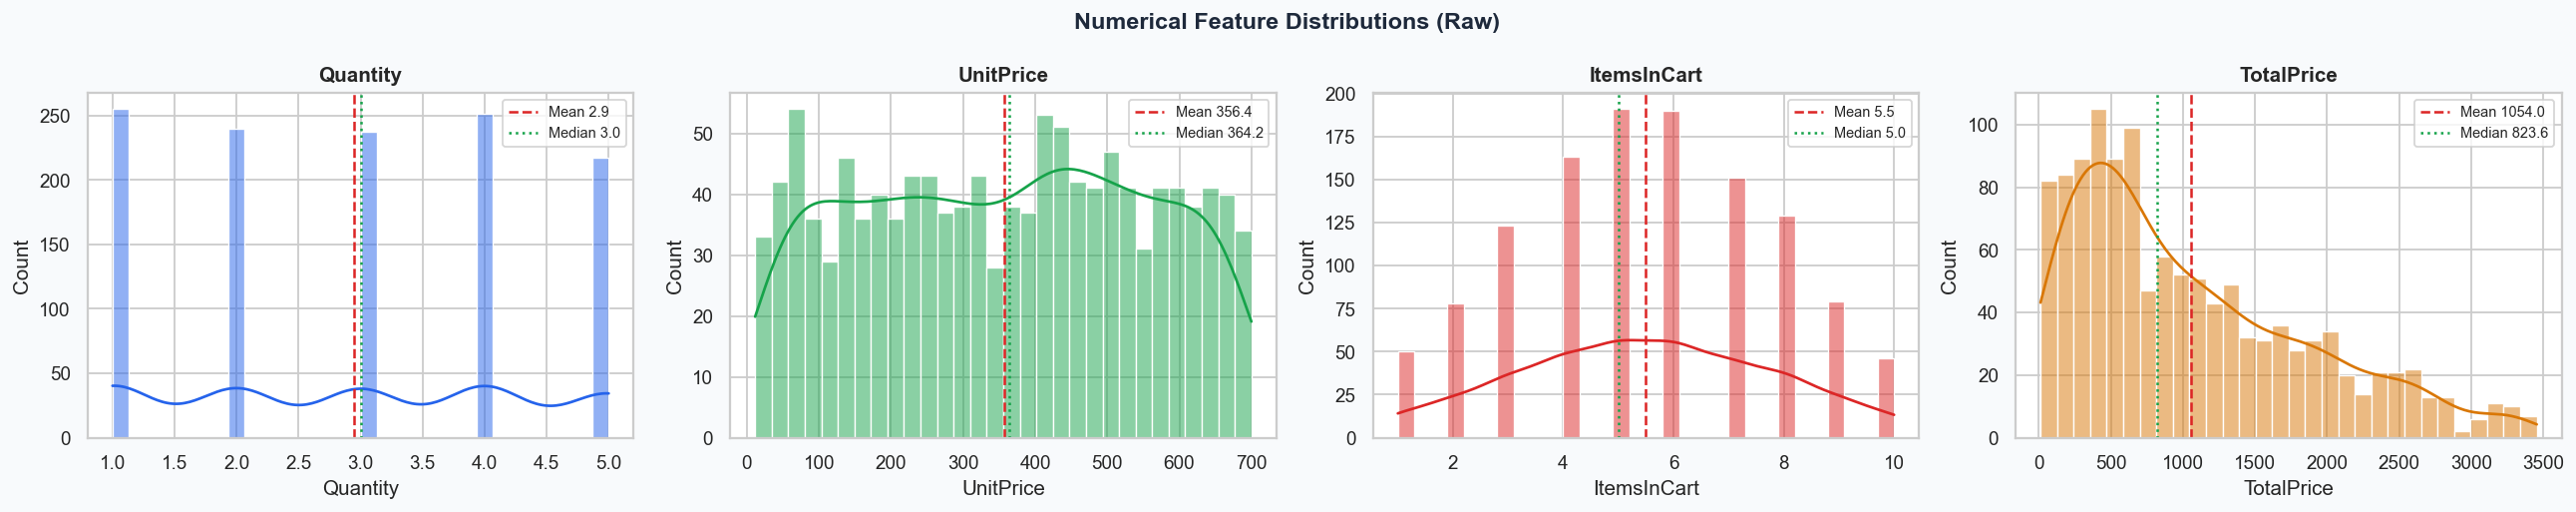

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Numerical Feature Distributions (Raw)', fontsize=13, fontweight='bold', color='#1E293B')
for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color=PALETTE[i], bins=30, edgecolor='white')
    ax.axvline(df[col].mean(),   color='#DC2626', ls='--', lw=1.4, label=f'Mean {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='#16A34A', ls=':',  lw=1.4, label=f'Median {df[col].median():.1f}')
    ax.set_title(col, fontweight='bold'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

C:\Users\power\AppData\Local\Temp\ipykernel_15160\2930859943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, ax=axes[j], palette=PALETTE[:len(vc)], orient='h')
C:\Users\power\AppData\Local\Temp\ipykernel_15160\2930859943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, ax=axes[j], palette=PALETTE[:len(vc)], orient='h')
C:\Users\power\AppData\Local\Temp\ipykernel_15160\2930859943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, ax=axes[j], palette=PALETTE[:le

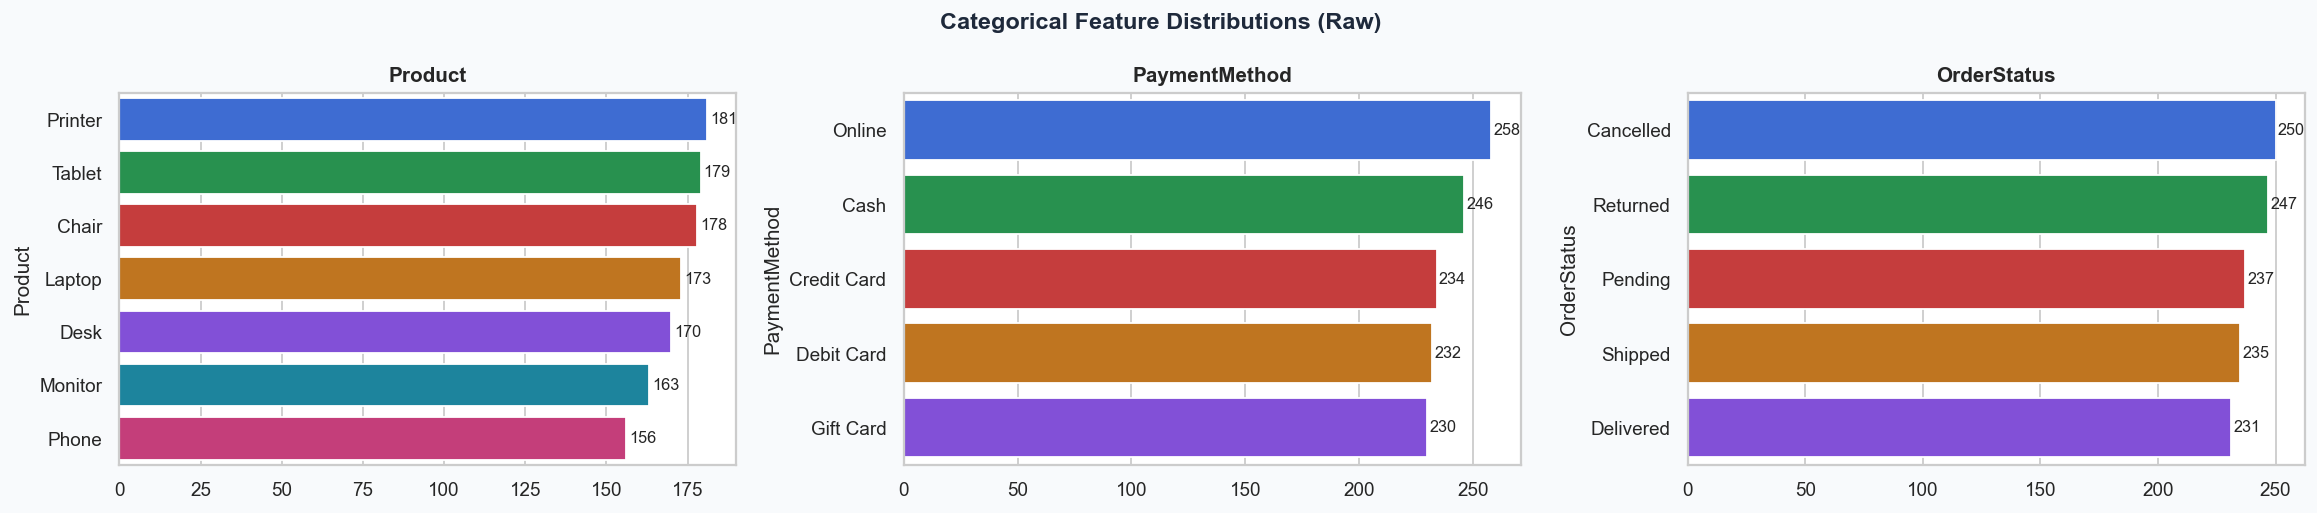

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('Categorical Feature Distributions (Raw)', fontsize=13, fontweight='bold', color='#1E293B')
for j, col in enumerate(['Product','PaymentMethod','OrderStatus']):
    vc = df[col].value_counts()
    sns.barplot(x=vc.values, y=vc.index, ax=axes[j], palette=PALETTE[:len(vc)], orient='h')
    axes[j].set_title(col, fontweight='bold')
    for p in axes[j].patches:
        axes[j].text(p.get_width()+1, p.get_y()+p.get_height()/2, str(int(p.get_width())), va='center', fontsize=9)
plt.tight_layout(); plt.show()

## ***1.3 Missing & Duplicate Profiling***

In [9]:
missing = df.isnull().sum()
missing_pct = df.isnull().mean()*100
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print(f'Full-row duplicates : {df.duplicated().sum()}')
print(f'Duplicate OrderIDs  : {df[ID_COL].duplicated().sum()}\n')
miss_df[miss_df['Missing Count']>0]

Full-row duplicates : 0
Duplicate OrderIDs  : 0



,Missing Count,Missing %
CouponCode,309,25.75


In [19]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

## ***1.4 Correlation & Anomaly Detection***

In [20]:
corr = df[NUM_COLS].corr()
corr.round(3)

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000,0.015,0.650,0.615
UnitPrice,0.015,1.000,0.001,0.717
ItemsInCart,0.650,0.001,1.000,0.393
TotalPrice,0.615,0.717,0.393,1.000


In [21]:
rows = []
for col in NUM_COLS:
    q1,q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3-q1
    lo,hi = q1-1.5*iqr, q3+1.5*iqr
    n_out = int(((df[col]<lo)|(df[col]>hi)).sum())
    has_out = n_out>0
    rows.append({'Feature': col, 'Lower Fence': round(lo,2), 'Upper Fence': round(hi,2),
                 'Outliers': n_out, 'Imputation Method': 'MEDIAN' if has_out else 'MEAN'})
outlier_df = pd.DataFrame(rows).set_index('Feature')
outlier_df

,Lower Fence,Upper Fence,Outliers,Imputation Method
Feature,,,,
Quantity,-1.00,7.00,0,MEAN
UnitPrice,-317.20,1024.83,0,MEAN
ItemsInCart,-0.50,11.50,0,MEAN
TotalPrice,-1341.41,3330.41,8,MEDIAN


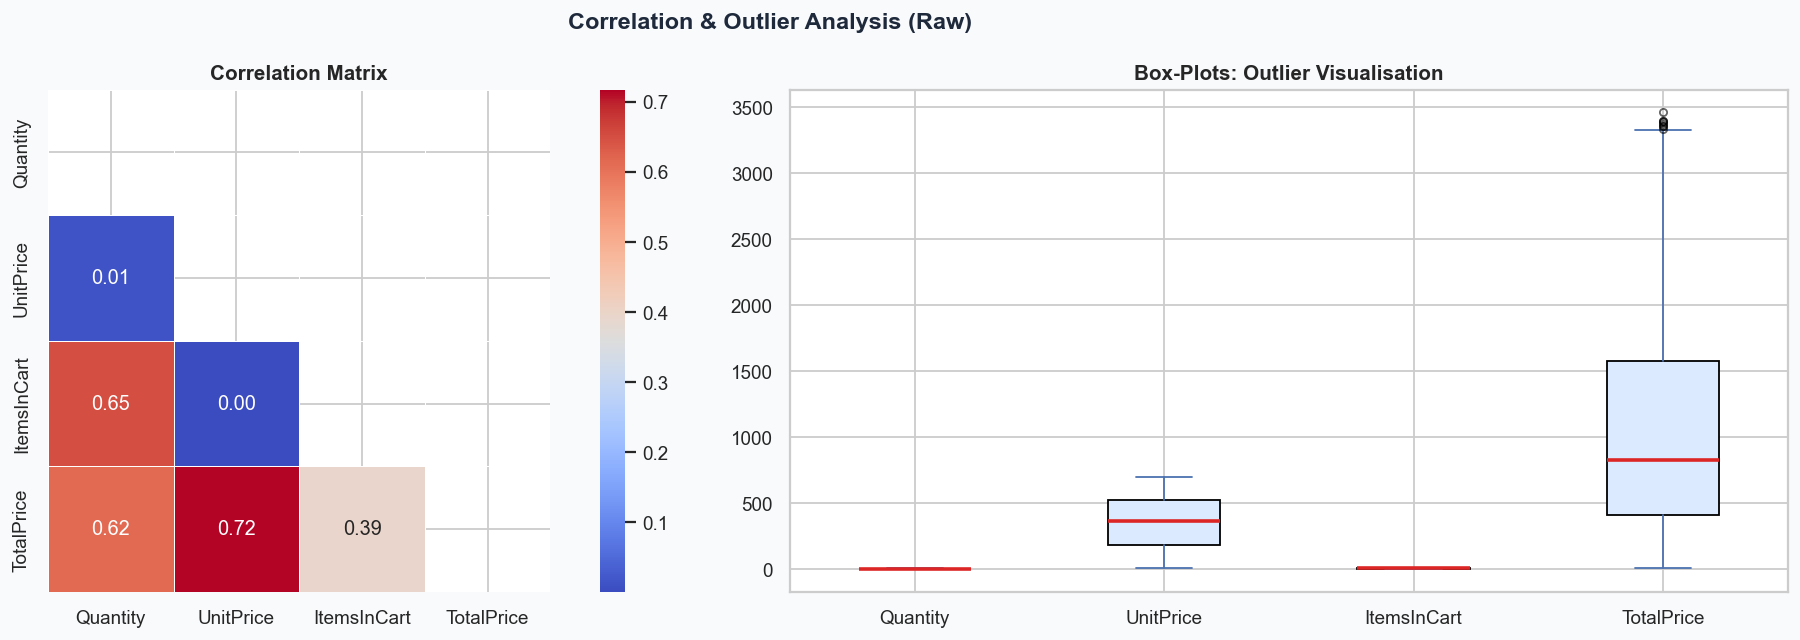

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Correlation & Outlier Analysis (Raw)', fontsize=13, fontweight='bold', color='#1E293B')

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0],
            mask=mask, square=True, linewidths=0.5, annot_kws={'size':11})
axes[0].set_title('Correlation Matrix', fontweight='bold')

# Box plots
df[NUM_COLS].plot(kind='box', ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='#DBEAFE'), medianprops=dict(color='#DC2626',lw=2),
    flierprops=dict(marker='o', color='#DC2626', markersize=4, alpha=0.6))
axes[1].set_title('Box-Plots: Outlier Visualisation', fontweight='bold')
plt.tight_layout(); plt.show()

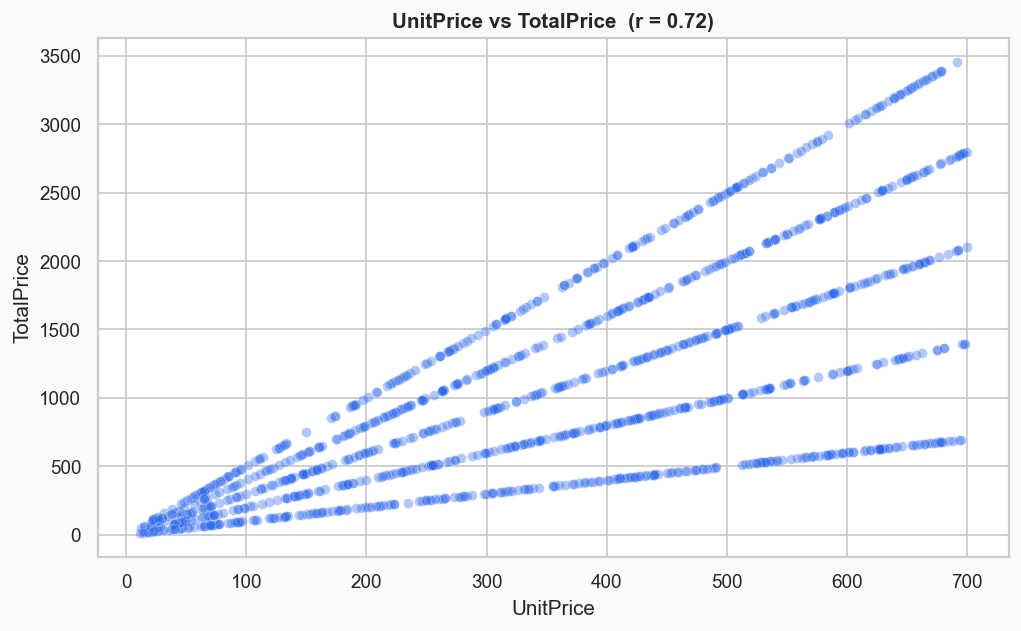

In [23]:
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(df['UnitPrice'], df['TotalPrice'], alpha=0.35, color=PALETTE[0], edgecolors='white', linewidth=0.3, s=30)
ax.set_xlabel('UnitPrice'); ax.set_ylabel('TotalPrice')
ax.set_title('UnitPrice vs TotalPrice  (r = 0.72)', fontweight='bold')
plt.tight_layout(); plt.show()

#  **Phase 2 —  Data Integrity Pipeline**
## ***Step 1 — Strategic Imputation***

In [24]:
def detect_outliers(series):
    q1,q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3-q1
    return bool(((series<q1-1.5*iqr)|(series>q3+1.5*iqr)).any())

outlier_flags = {col: detect_outliers(df[col].dropna()) for col in NUM_COLS}

df_clean = df.copy()
log = []
for col in NUM_COLS:
    n = df_clean[col].isnull().sum()
    if n==0: log.append({'Column':col,'Nulls Filled':0,'Method':'—','Fill Value':'—'}); continue
    m = 'MEDIAN' if outlier_flags[col] else 'MEAN'
    v = df_clean[col].median() if outlier_flags[col] else df_clean[col].mean()
    df_clean[col] = df_clean[col].fillna(v)
    log.append({'Column':col,'Nulls Filled':n,'Method':m,'Fill Value':round(v,4)})

for col in CAT_COLS:
    n = df_clean[col].isnull().sum()
    if n==0: log.append({'Column':col,'Nulls Filled':0,'Method':'—','Fill Value':'—'}); continue
    v = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(v)
    log.append({'Column':col,'Nulls Filled':n,'Method':'MODE','Fill Value':v})

pd.DataFrame(log).set_index('Column')

,Nulls Filled,Method,Fill Value
Column,,,
Quantity,0,—,—
UnitPrice,0,—,—
ItemsInCart,0,—,—
TotalPrice,0,—,—
Product,0,—,—
PaymentMethod,0,—,—
OrderStatus,0,—,—
CouponCode,309,MODE,FREESHIP
ReferralSource,0,—,—


In [27]:
print(f'Nulls before : {df.isnull().sum().sum()}')
print(f'Nulls after  : {df_clean.isnull().sum().sum()}')

Nulls before : 309
Nulls after  : 0


# ***Step 2 — Integrity Audit (Deduplication)***

In [28]:
before = len(df_clean)
n_dup  = df_clean[ID_COL].duplicated().sum()
df_clean = df_clean.drop_duplicates(subset=[ID_COL], keep='first').reset_index(drop=True)
print(f'Duplicate OrderIDs found : {n_dup}')
print(f'Rows before : {before:,}  →  Rows after : {len(df_clean):,}  (removed: {before-len(df_clean)})')
print(f'OrderID uniqueness guaranteed')

Duplicate OrderIDs found : 0
Rows before : 1,200  →  Rows after : 1,200  (removed: 0)
OrderID uniqueness guaranteed


## ***Step 3 — Data Standardisation***

In [29]:
df_clean[DATE_COL] = pd.to_datetime(df_clean[DATE_COL], errors='coerce').dt.strftime('%Y-%m-%d')
print(f'Date column  → ISO 8601 YYYY-MM-DD  |  unparseable: {df_clean[DATE_COL].isnull().sum()}')

for col in TEXT_PROP:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
for col in [ID_COL,'CustomerID','TrackingNumber','ShippingAddress']:
    df_clean[col] = df_clean[col].astype(str).str.strip()
print('Text columns → stripped + Title Case applied')


for col in FINANCIAL:
    df_clean[col] = df_clean[col].round(2)
print('Financial columns → 2 decimal places')

df_clean.head()

Date column  → ISO 8601 YYYY-MM-DD  |  unparseable: 0
Text columns → stripped + Title Case applied
Financial columns → 2 decimal places


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,Save10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,Save10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,Freeship,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,Save10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,Save10,Email,2504.04



# **Verification Summary**

In [30]:
ISO_PAT = r'^\d{4}-\d{2}-\d{2}$'

results = {
    'Duplicate OrderIDs'         : df_clean[ID_COL].duplicated().sum(),
    'Incorrectly formatted dates': int((~df_clean[DATE_COL].str.match(ISO_PAT, na=False)).sum()),
    'Remaining null values'      : df_clean.isnull().sum().sum(),
    'Rows removed (no deletion)' : len(df)-len(df_clean),
}

verdict = pd.DataFrame({
    'Result'  : results.values(),
    'Expected': [0,0,0,0],
}, index=results.keys())

print(f"Final dataset shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns\n")
verdict

Final dataset shape: 1,200 rows × 14 columns



,Result,Expected
Duplicate OrderIDs,0,0
Incorrectly formatted dates,0,0
Remaining null values,0,0
Rows removed (no deletion),0,0


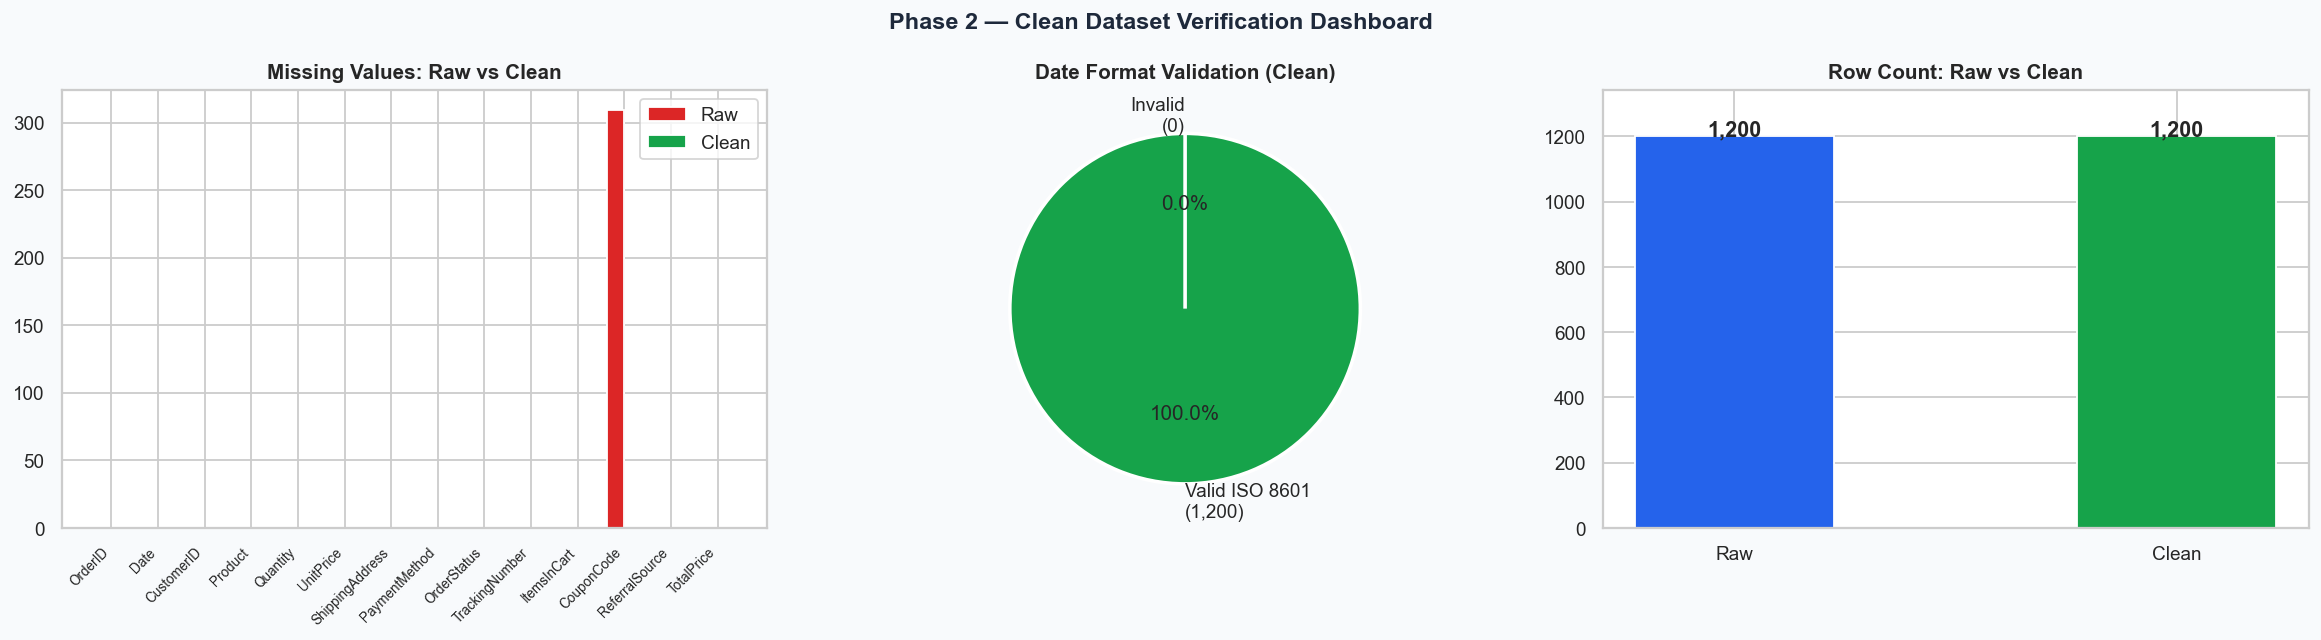

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phase 2 — Clean Dataset Verification Dashboard', fontsize=13, fontweight='bold', color='#1E293B')

labels = df.columns.tolist()
x = np.arange(len(labels)); w=0.38
axes[0].bar(x-w/2, df.isnull().sum().values, w, label='Raw',   color=PALETTE[2], edgecolor='white')
axes[0].bar(x+w/2, df_clean.isnull().sum().reindex(df.columns, fill_value=0).values, w, label='Clean', color=PALETTE[1], edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=7.5)
axes[0].set_title('Missing Values: Raw vs Clean', fontweight='bold'); axes[0].legend()


valid = df_clean[DATE_COL].str.match(ISO_PAT, na=False).sum()
invalid = len(df_clean)-valid
axes[1].pie([valid,invalid], labels=[f'Valid ISO 8601\n({valid:,})',f'Invalid\n({invalid})'],
            autopct='%1.1f%%', colors=[PALETTE[1], PALETTE[2]],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Date Format Validation (Clean)', fontweight='bold')


rc = {'Raw': len(df), 'Clean': len(df_clean)}
bars = axes[2].bar(rc.keys(), rc.values(), color=[PALETTE[0],PALETTE[1]], edgecolor='white', width=0.45)
for b in bars:
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()+2, f'{int(b.get_height()):,}',
                 ha='center', fontsize=12, fontweight='bold')
axes[2].set_title('Row Count: Raw vs Clean', fontweight='bold')
axes[2].set_ylim(0, max(rc.values())*1.12)
plt.tight_layout(); plt.show()